In [2]:
# ==============================
# DATASET AUDIT - CONFIGURATION
# ==============================

import os
from pathlib import Path

# Define project root (one level above notebooks)
PROJECT_ROOT = Path().resolve().parent

# Define dataset path (we will use only COLOR dataset)
DATASET_PATH = PROJECT_ROOT / "data" / "raw" / "plantvillage dataset" / "color"

print("Project Root:", PROJECT_ROOT)
print("Dataset Path:", DATASET_PATH)


Project Root: C:\Users\anish\OneDrive\Desktop\plantvillage
Dataset Path: C:\Users\anish\OneDrive\Desktop\plantvillage\data\raw\plantvillage dataset\color


In [3]:
# ==============================
# CLASS AUDIT
# ==============================

class_names = sorted([folder.name for folder in DATASET_PATH.iterdir() if folder.is_dir()])

num_classes = len(class_names)

print("Number of Classes:", num_classes)
print("\nAll Class Names:\n")

for cls in class_names:
    print(cls)



Number of Classes: 38

All Class Names:

Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___Leaf_scorch
Strawberry___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosai

In [4]:
# ==============================
# IMAGE COUNT AUDIT
# ==============================

from collections import defaultdict

image_count_per_class = {}
total_images = 0

for class_name in class_names:
    class_path = DATASET_PATH / class_name
    images = [img for img in class_path.iterdir() if img.is_file()]
    
    count = len(images)
    image_count_per_class[class_name] = count
    total_images += count

print("Total Images:", total_images)
print("\nImages per Class:\n")

for cls, count in image_count_per_class.items():
    print(f"{cls}: {count}")


Total Images: 54305

Images per Class:

Apple___Apple_scab: 630
Apple___Black_rot: 621
Apple___Cedar_apple_rust: 275
Apple___healthy: 1645
Blueberry___healthy: 1502
Cherry_(including_sour)___Powdery_mildew: 1052
Cherry_(including_sour)___healthy: 854
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513
Corn_(maize)___Common_rust_: 1192
Corn_(maize)___Northern_Leaf_Blight: 985
Corn_(maize)___healthy: 1162
Grape___Black_rot: 1180
Grape___Esca_(Black_Measles): 1383
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076
Grape___healthy: 423
Orange___Haunglongbing_(Citrus_greening): 5507
Peach___Bacterial_spot: 2297
Peach___healthy: 360
Pepper,_bell___Bacterial_spot: 997
Pepper,_bell___healthy: 1478
Potato___Early_blight: 1000
Potato___Late_blight: 1000
Potato___healthy: 152
Raspberry___healthy: 371
Soybean___healthy: 5090
Squash___Powdery_mildew: 1835
Strawberry___Leaf_scorch: 1109
Strawberry___healthy: 456
Tomato___Bacterial_spot: 2127
Tomato___Early_blight: 1000
Tomato___Late_blight: 1909
T

In [5]:
# ==============================
# IMBALANCE ANALYSIS
# ==============================

min_class = min(image_count_per_class, key=image_count_per_class.get)
max_class = max(image_count_per_class, key=image_count_per_class.get)

min_count = image_count_per_class[min_class]
max_count = image_count_per_class[max_class]

imbalance_ratio = round(max_count / min_count, 2)

print("Smallest Class:", min_class, "→", min_count)
print("Largest Class:", max_class, "→", max_count)
print("Imbalance Ratio (max/min):", imbalance_ratio)


Smallest Class: Potato___healthy → 152
Largest Class: Orange___Haunglongbing_(Citrus_greening) → 5507
Imbalance Ratio (max/min): 36.23


In [ ]:
# ==============================
# IMAGE DIMENSION AUDIT (SAMPLED)
# ==============================

from PIL import Image
from collections import Counter
import random

image_sizes = []
corrupted_images = 0

all_image_paths = []

for class_name in class_names:
    class_path = DATASET_PATH / class_name
    for img_path in class_path.iterdir():
        all_image_paths.append(img_path)

# Randomly sample 1000 images (or less if dataset smaller)
sample_paths = random.sample(all_image_paths, min(1000, len(all_image_paths)))

for img_path in sample_paths:
    try:
        with Image.open(img_path) as img:
            image_sizes.append(img.size)
    except:
        corrupted_images += 1

size_counter = Counter(image_sizes)

print("Sampled Images Checked:", len(sample_paths))
print("Unique Image Dimensions Found:", len(size_counter))
print("Most Common Dimensions:", size_counter.most_common(5))
print("Corrupted Images in Sample:", corrupted_images)


Sampled Images Checked: 1000
Unique Image Dimensions Found: 1
Most Common Dimensions: [((256, 256), 1000)]
Corrupted Images in Sample: 0


In [7]:
# ==============================
# CHANNEL AUDIT (RGB CHECK)
# ==============================

channel_counts = []

for img_path in sample_paths:
    with Image.open(img_path) as img:
        channel_counts.append(len(img.getbands()))

from collections import Counter
channel_counter = Counter(channel_counts)

print("Channel Distribution in Sample:")
print(channel_counter)


Channel Distribution in Sample:
Counter({3: 1000})


In [8]:
# ==============================
# PIXEL VALUE AUDIT
# ==============================

import numpy as np

pixel_mins = []
pixel_maxs = []

for img_path in sample_paths[:200]:  # Check 200 images for speed
    with Image.open(img_path) as img:
        img_array = np.array(img)
        pixel_mins.append(img_array.min())
        pixel_maxs.append(img_array.max())

print("Minimum Pixel Value in Sample:", min(pixel_mins))
print("Maximum Pixel Value in Sample:", max(pixel_maxs))
print("Data Type:", img_array.dtype)


Minimum Pixel Value in Sample: 0
Maximum Pixel Value in Sample: 255
Data Type: uint8


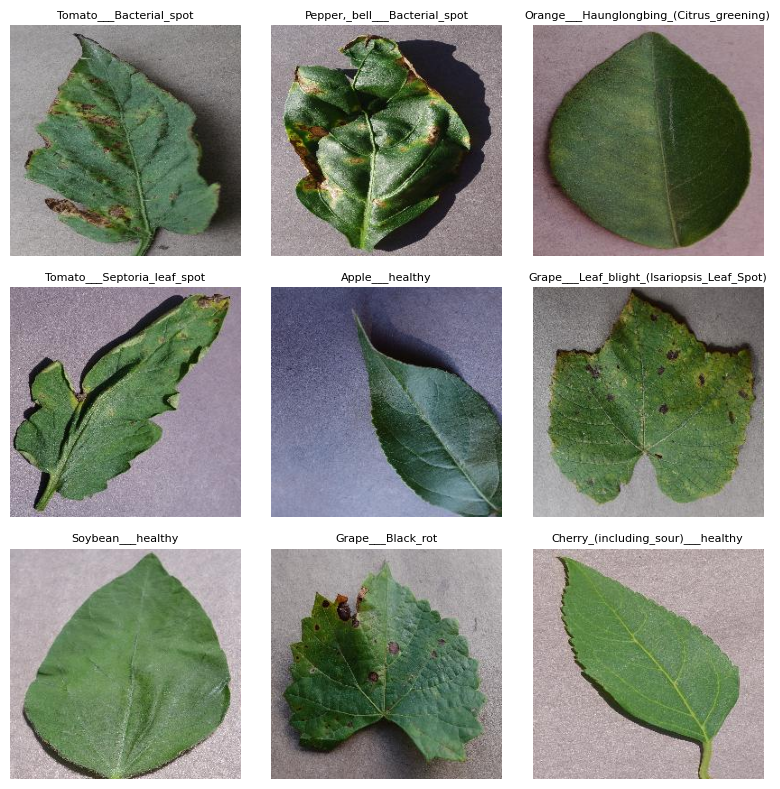

In [9]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# Select 9 random images
sample_images = random.sample(sample_paths, 9)

plt.figure(figsize=(8,8))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)
    
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(img_path.parent.name, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()


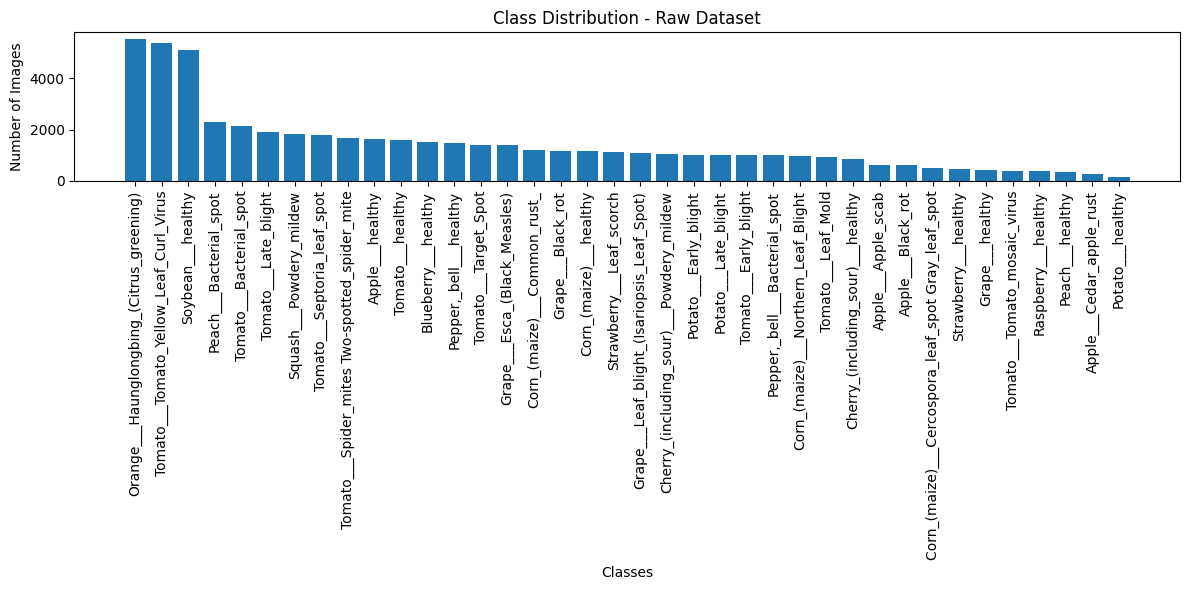

In [10]:
import matplotlib.pyplot as plt

# Sort classes by count
sorted_counts = dict(sorted(image_count_per_class.items(), 
                            key=lambda x: x[1], 
                            reverse=True))

plt.figure(figsize=(12,6))
plt.bar(sorted_counts.keys(), sorted_counts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution - Raw Dataset")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()
